#                                Titanic_Passenger Survival_Analysis -

# Objective: Investigate survival probabilities by family size and ticket fare groups to identify how family connections and socio-economic status influenced survival during the Titanic disaster. :

### loading the dataset :

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
Titanic_dataset =r"C:\Users\soume\Downloads\titanic- dataset\Titanic-Dataset.csv"
data = pd.read_csv(Titanic_dataset)

### Preview the dataset :

In [3]:
print(data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


# Create new Columns :

In [5]:
# Create Family Size column
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

In [6]:
# Categorize fares into groups
data['FareGroup'] = pd.cut(
    data['Fare'],
    bins=[-1, 10, 30, 100, data['Fare'].max()],
    labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High']
)
data.head(12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FareGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,Upper-Middle
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Low
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Upper-Middle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Low
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,1,Low
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1,Upper-Middle
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,5,Lower-Middle
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,3,Lower-Middle
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,2,Upper-Middle


# Handle Missing Values :

### Find Missing Values :

In [7]:
print(data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
FareGroup        0
dtype: int64


In [8]:
# Fill missing 'Age' with median :
data['Age'].fillna(data['Age'].median(),inplace=True)

In [9]:
# Drop 'Cabin' due to many missing values :
data.drop(columns=['Cabin'],inplace=True)

In [10]:
#  Fill missing 'Embarked' with mode :
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace= True)
data.head(12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,FareGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,Upper-Middle
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Low
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,Upper-Middle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Low
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,1,Low
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,1,Upper-Middle
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,5,Lower-Middle
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,3,Lower-Middle
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,2,Upper-Middle


#  Analyze Survival by Family Size :

In [11]:
# # Group by FamilySize and calculate survival rates :
family_survival = data.groupby('FamilySize')['Survived'].mean()
print(family_survival)

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


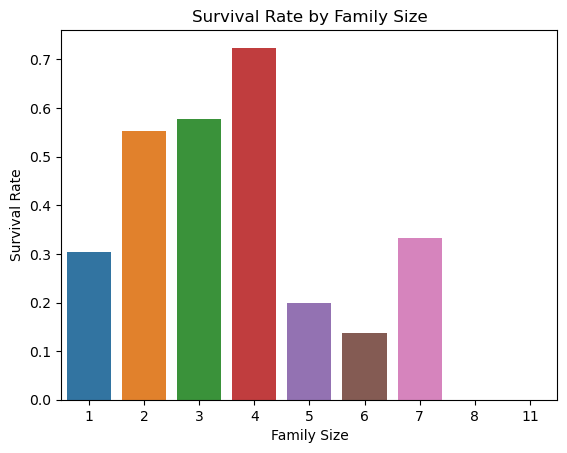

In [12]:
# Visualize survival rate by family size :
sns.barplot(x=family_survival.index, y=family_survival.values)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

## Key Insights:
  ## Family Size: Passengers with small families (1-4 members) had the highest survival rates. Large families (>4) had lower survival chances.

# Analyze Survival by Fare Groups :

In [13]:
# Group by FareGroup and calculate survival rates
fare_survival = data.groupby('FareGroup', observed=True)['Survived'].mean()
print(fare_survival)


FareGroup
Low             0.199405
Lower-Middle    0.433022
Upper-Middle    0.535912
High            0.735849
Name: Survived, dtype: float64


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


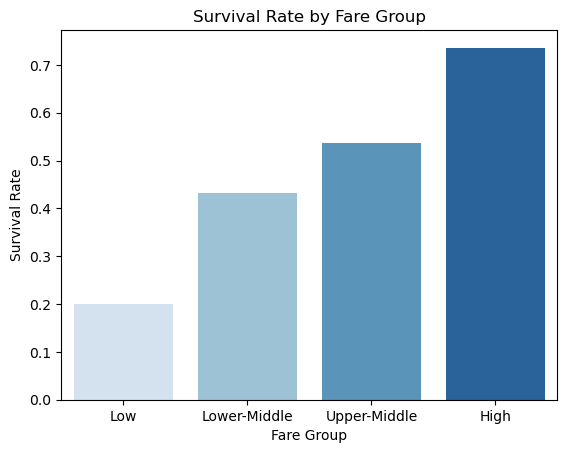

In [14]:
# Visualize survival rate by fare group
fare_survival = data.groupby('FareGroup', observed=True)['Survived'].mean()

sns.barplot(x=fare_survival.index, y=fare_survival.values, palette='Blues')
plt.title('Survival Rate by Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate')
plt.show()


## Key Insights :
  ### Fare Group: Higher fare groups are with better survival probabilities,then lower fare groups. That's indicating a socio-economic divide.

 # Calculate Survival Rates Group by Gender :


In [15]:
# Group by Gender and calculate survival rates
gender_survival = data.groupby('Sex')['Survived'].mean()
print(gender_survival)

# Total count of passengers by gender
gender_counts = data['Sex'].value_counts()
print(gender_counts)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Sex
male      577
female    314
Name: count, dtype: int64


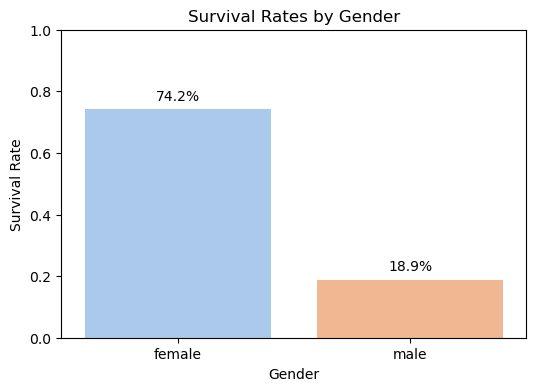

In [16]:
# Plot survival rates by gender
plt.figure(figsize=(6, 4))
sns.barplot(x=gender_survival.index, y=gender_survival.values, palette='pastel')
for i, value in enumerate(gender_survival.values):
    plt.text(i, value + 0.02, f'{value * 100:.1f}%', ha='center', va='bottom', fontsize=10)
plt.title('Survival Rates by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

## Key Insights: Females generally had a significantly higher survival rate compared to males due to evacuation protocols prioritizing "women and children first."

# Age distribution among survivors and non-survivors :

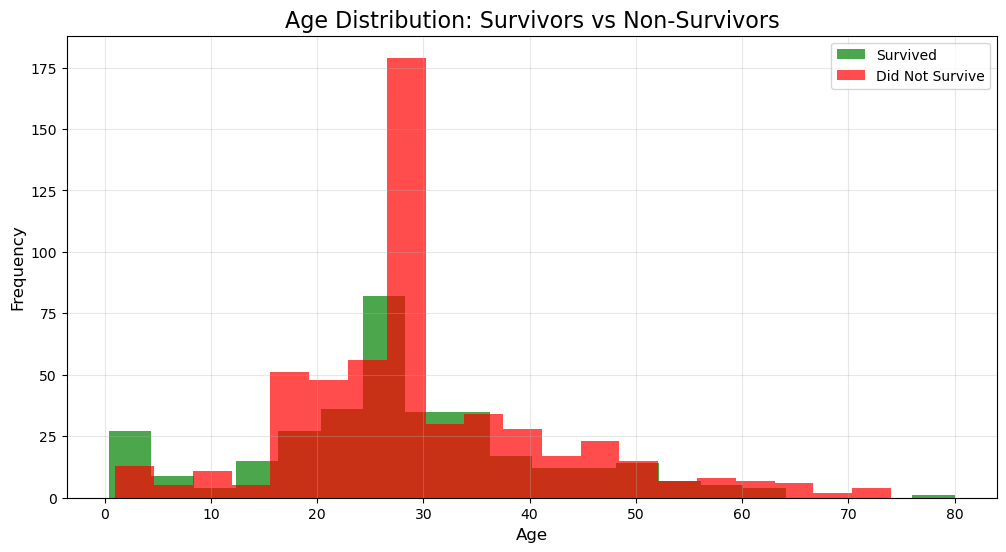

In [18]:
# Check if the necessary columns exist
if 'Age' in data.columns and 'Survived' in data.columns:
    # Separate the data into survivors and non-survivors
    survivors = data[data['Survived'] == 1]['Age']
    non_survivors = data[data['Survived'] == 0]['Age']
    
    # Plotting the histograms
    plt.figure(figsize=(12, 6))
    
    plt.hist(survivors, bins=20, alpha=0.7, label='Survived', color='green')
    plt.hist(non_survivors, bins=20, alpha=0.7, label='Did Not Survive', color='red')
    
    plt.title('Age Distribution: Survivors vs Non-Survivors', fontsize=16)
    plt.xlabel('Age', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("The necessary columns ('Age' and 'Survived') are not present in the dataset.")

## Key Insight: The survival rate decreases as age increases, except for children, who had a better chance of survival.

# Combine Family Size and Fare Group Analysis :

In [19]:
# Group by both FamilySize and FareGroup
combined_survival = data.groupby(['FamilySize', 'FareGroup'],observed=True)['Survived'].mean().unstack()
print(combined_survival)

FareGroup        Low  Lower-Middle  Upper-Middle      High
FamilySize                                                
1           0.196141      0.381579      0.534483  0.812500
2           0.294118      0.436620      0.724138  0.733333
3           0.000000      0.612903      0.625000  0.666667
4                NaN      0.666667      0.857143  0.714286
5                NaN      0.111111      0.000000  1.000000
6                NaN      0.083333      0.000000  0.500000
7           1.000000           NaN      0.272727       NaN
8                NaN           NaN      0.000000       NaN
11               NaN           NaN      0.000000       NaN


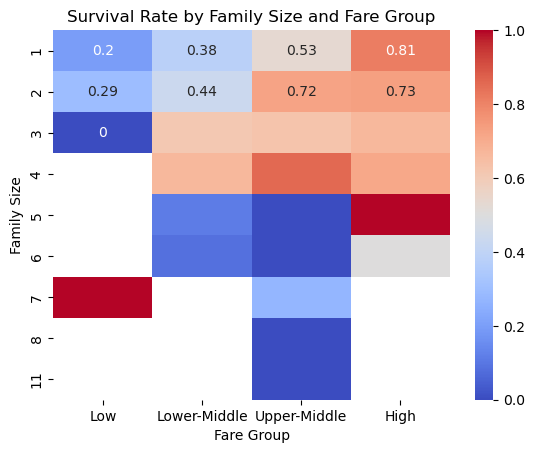

In [20]:
# Visualize combined survival rates
sns.heatmap(combined_survival, annot=True, cmap='coolwarm')
plt.title('Survival Rate by Family Size and Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Family Size')
plt.show()

## Key Insights :
 ## Combined Analysis:  Small families in the higher fare groups had the best survival rates, whereas large families in lower fare groups were least likely to survive.